# K-Means Clustering: A Simple Explanation 💡

We will build K-Means step-by-step using the most explicit and simple logic possible.

**The Goal**: Group data points into `K` clusters.
**The Method**: Iteratively move `centroids` (center of clusters) until they find the best position.

We have 300 data points, each with 2 features (x, y coordinates).


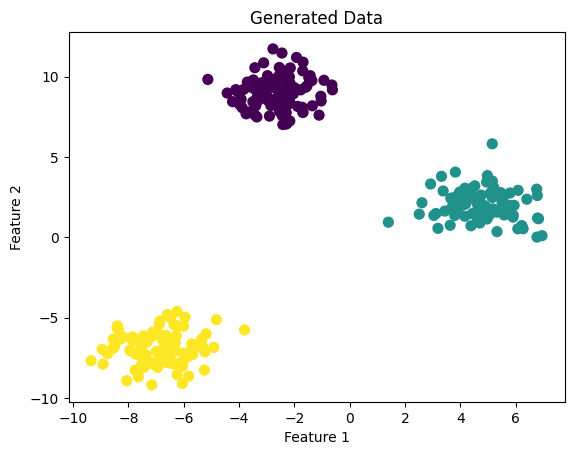

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

np.random.seed(42)
%matplotlib inline

# 1. Generate Data
X, y = make_blobs(centers=3, n_samples=300, n_features=2, shuffle=True, random_state=42)
print(f"We have {X.shape[0]} data points, each with {X.shape[1]} features (x, y coordinates).")

# 2. Visualize Data
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=50)
plt.title('Generated Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()


## Step 1: Initialization 🌟

We need to start somewhere. We pick `K` random points from our dataset to be the initial **centroids**.

In [32]:
def initialize_centroids(X, k):
    # Select k random indices from the data
    indices = np.random.choice(X.shape[0], k, replace=False)
    # Use the data points at those indices as our starting centroids
    print('Initial centroids: ', X[indices])

    return X[indices]

## Step 2: Assignment 👈

For every single data point, we measure its distance to all centroids. We assign the point to the **closest** centroid.

We store this assignment in an array called `assigned_clusters`. If point `i` belongs to cluster `0`, then `assigned_clusters[i] = 0`.

In [33]:
def assign_clusters(X, centroids):
    n_samples = X.shape[0]
    k = len(centroids)
    assigned_clusters = np.zeros(n_samples, dtype=int)

    for i in range(n_samples):
        # 1. Get the current point
        point = X[i]
        
        # 2. Measure distance to every centroid
        distances = []
        for centroid in centroids:
            dist = np.sqrt(np.sum((point - centroid) ** 2)) # Euclidean Distance
            distances.append(dist)
        
        # 3. Find the index of the smallest distance
        closest_centroid_index = np.argmin(distances)
        
        # 4. Save that index as the cluster for this point
        assigned_clusters[i] = closest_centroid_index
        
        print(f"Point {i} is assigned to cluster {closest_centroid_index}")
    return assigned_clusters

## Step 3: Update Centroids 📈

Now that every point has a cluster, we need to find the **new center** of that cluster.
We do this by calculating the **mean** (average) of all points belonging to that cluster.

In [34]:
def update_centroids(X, assigned_clusters, k):
    n_features = X.shape[1]
    new_centroids = np.zeros((k, n_features))
    
    for cluster_id in range(k):
        # Get all points that were assigned to this cluster_id
        points_in_cluster = X[assigned_clusters == cluster_id]
        
        # Calculate their mean (average position)
        if len(points_in_cluster) > 0:
            new_centroids[cluster_id] = np.mean(points_in_cluster, axis=0)
        else:
            # Handle case where a cluster has no points (rare but possible)
            new_centroids[cluster_id] = np.zeros(n_features)

        print(f"Cluster {cluster_id}: {len(points_in_cluster)} points")
            
    return new_centroids

## Visualization Helper 👀

A simple function to plot our data points (colored by their cluster) and the centroids (marked with an X).

In [35]:
def plot_kmeans(X, assigned_clusters, centroids, iteration_title):
    plt.figure(figsize=(8, 5))
    
    # Plot data points
    # We use 'c=assigned_clusters' to automatically color by group
    plt.scatter(X[:, 0], X[:, 1], c=assigned_clusters, cmap='viridis', s=30, label='Data Points')
    
    # Plot centroids
    plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='x', s=200, linewidth=3, label='Centroids')
    
    plt.title(iteration_title)
    plt.legend()
    plt.show()

## Putting It All Together 🚀

Now we run the loop!
1. Initialize
2. Loop: Assign -> Update -> Plot -> Check Convergence

Initial centroids:  [[ 4.05051408  2.82277178]
 [-6.75933156 -6.36567076]
 [ 4.9208707   1.35047016]]
Point 0 is assigned to cluster 1
Point 1 is assigned to cluster 1
Point 2 is assigned to cluster 0
Point 3 is assigned to cluster 0
Point 4 is assigned to cluster 1
Point 5 is assigned to cluster 2
Point 6 is assigned to cluster 0
Point 7 is assigned to cluster 2
Point 8 is assigned to cluster 0
Point 9 is assigned to cluster 0
Point 10 is assigned to cluster 0
Point 11 is assigned to cluster 2
Point 12 is assigned to cluster 0
Point 13 is assigned to cluster 0
Point 14 is assigned to cluster 1
Point 15 is assigned to cluster 0
Point 16 is assigned to cluster 1
Point 17 is assigned to cluster 0
Point 18 is assigned to cluster 0
Point 19 is assigned to cluster 0
Point 20 is assigned to cluster 0
Point 21 is assigned to cluster 0
Point 22 is assigned to cluster 2
Point 23 is assigned to cluster 1
Point 24 is assigned to cluster 0
Point 25 is assigned to cluster 1
Point 26 is assigned to 

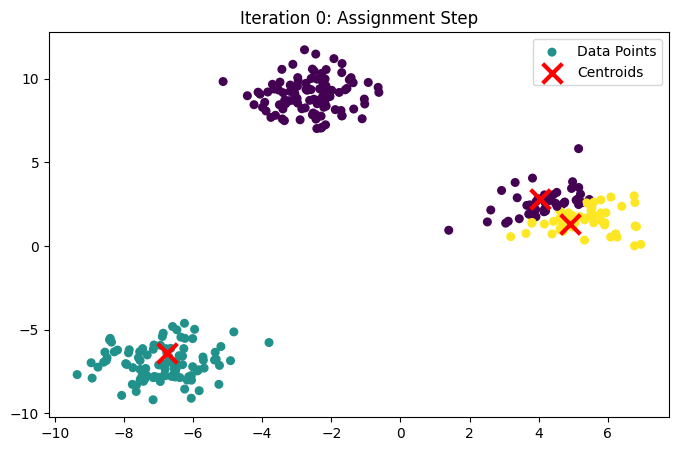

Cluster 0: 145 points
Cluster 1: 100 points
Cluster 2: 55 points


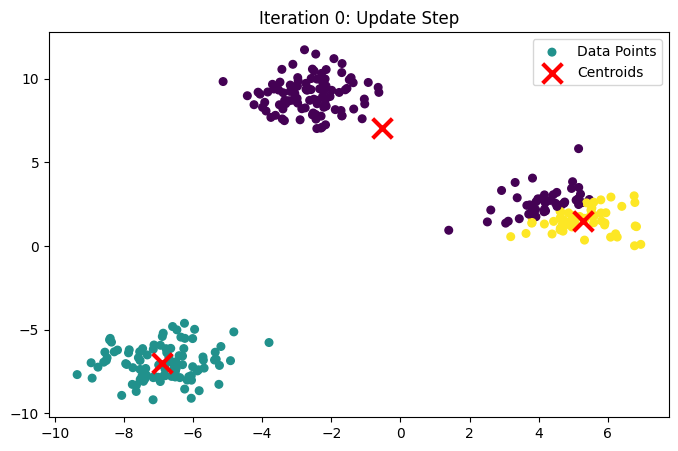

Iteration 0: Centroids moved by 10.0844
Point 0 is assigned to cluster 1
Point 1 is assigned to cluster 1
Point 2 is assigned to cluster 0
Point 3 is assigned to cluster 2
Point 4 is assigned to cluster 1
Point 5 is assigned to cluster 2
Point 6 is assigned to cluster 0
Point 7 is assigned to cluster 2
Point 8 is assigned to cluster 0
Point 9 is assigned to cluster 0
Point 10 is assigned to cluster 0
Point 11 is assigned to cluster 2
Point 12 is assigned to cluster 0
Point 13 is assigned to cluster 0
Point 14 is assigned to cluster 1
Point 15 is assigned to cluster 0
Point 16 is assigned to cluster 1
Point 17 is assigned to cluster 2
Point 18 is assigned to cluster 0
Point 19 is assigned to cluster 0
Point 20 is assigned to cluster 0
Point 21 is assigned to cluster 0
Point 22 is assigned to cluster 2
Point 23 is assigned to cluster 1
Point 24 is assigned to cluster 0
Point 25 is assigned to cluster 1
Point 26 is assigned to cluster 1
Point 27 is assigned to cluster 2
Point 28 is assign

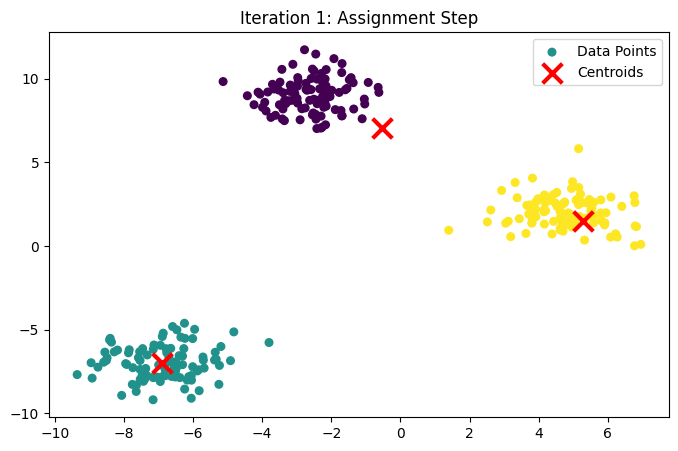

Cluster 0: 100 points
Cluster 1: 100 points
Cluster 2: 100 points


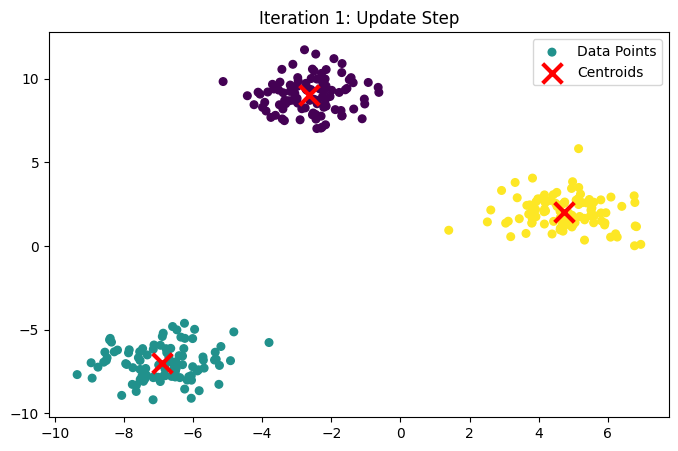

Iteration 1: Centroids moved by 5.0977
Point 0 is assigned to cluster 1
Point 1 is assigned to cluster 1
Point 2 is assigned to cluster 0
Point 3 is assigned to cluster 2
Point 4 is assigned to cluster 1
Point 5 is assigned to cluster 2
Point 6 is assigned to cluster 0
Point 7 is assigned to cluster 2
Point 8 is assigned to cluster 0
Point 9 is assigned to cluster 0
Point 10 is assigned to cluster 0
Point 11 is assigned to cluster 2
Point 12 is assigned to cluster 0
Point 13 is assigned to cluster 0
Point 14 is assigned to cluster 1
Point 15 is assigned to cluster 0
Point 16 is assigned to cluster 1
Point 17 is assigned to cluster 2
Point 18 is assigned to cluster 0
Point 19 is assigned to cluster 0
Point 20 is assigned to cluster 0
Point 21 is assigned to cluster 0
Point 22 is assigned to cluster 2
Point 23 is assigned to cluster 1
Point 24 is assigned to cluster 0
Point 25 is assigned to cluster 1
Point 26 is assigned to cluster 1
Point 27 is assigned to cluster 2
Point 28 is assigne

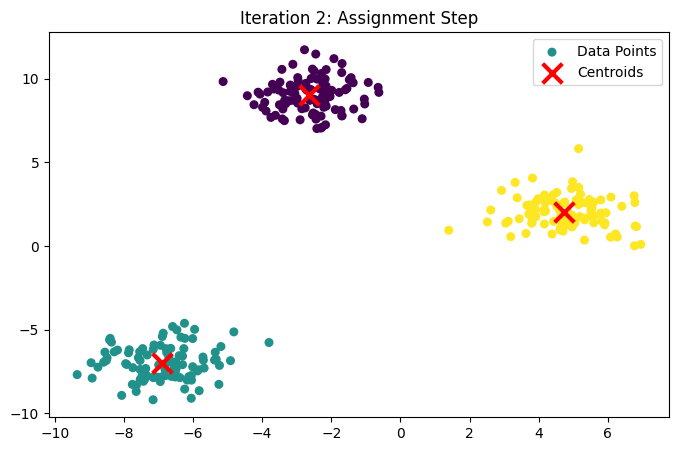

Cluster 0: 100 points
Cluster 1: 100 points
Cluster 2: 100 points


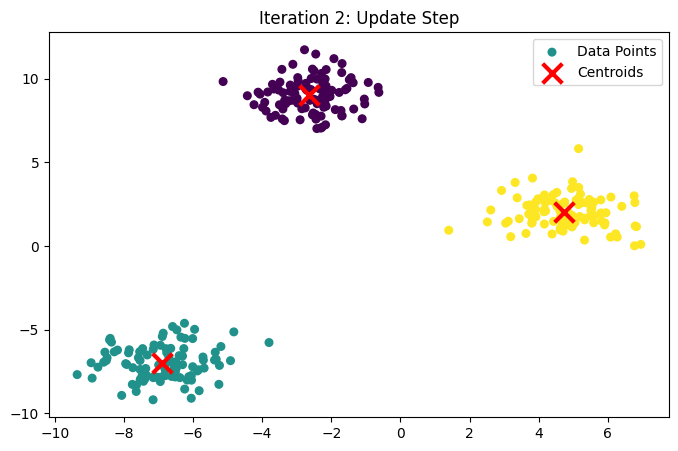

Iteration 2: Centroids moved by 0.0000
Converged! Stopping.


In [36]:
K = 3
MAX_ITERS = 10

# 1. Initialize Centroids
centroids = initialize_centroids(X, K)

for i in range(MAX_ITERS):
    # 2. Assignment Step
    # Assign each point to the closest centroid
    assigned_clusters = assign_clusters(X, centroids)
    
    plot_kmeans(X, assigned_clusters, centroids, f"Iteration {i}: Assignment Step")

    # 3. Update Step
    # Move centroids to the center of their assigned points
    old_centroids = centroids.copy()
    centroids = update_centroids(X, assigned_clusters, K)
    
    plot_kmeans(X, assigned_clusters, centroids, f"Iteration {i}: Update Step")
    
    # 4. Check Convergence
    # If centroids didn't move, we are done!
    # We compare the sum of differences between old and new positions
    movement = np.sum(np.abs(centroids - old_centroids))
    print(f"Iteration {i}: Centroids moved by {movement:.4f}")
    
    if movement == 0:
        print("Converged! Stopping.")
        break
